<a href="https://colab.research.google.com/github/pareshrnayak/English-to-Tulu-Translator/blob/main/Recognizing_Handwritten_Digits_using_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT: Recognizing Handwritten Digits using Scikit-Learn**

### **Team Members**

- **Paresh R Nayak**  
- **Karan N Bhandary**

### **Step 1: Loading Dataset**

In this step, we import the required libraries and load the handwritten digits dataset using Scikit-Learn. The dataset contains images of digits (0–9), where each image is represented as an $8 \times 8$ pixel grid.

The data is divided into two parts:

- **Features (X):** Represents the pixel values of each image.  
- **Labels (y):** Represents the actual digit corresponding to each image.  

This step initializes the dataset, which will be used for training and testing the machine learning model.

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
digits = load_digits()

# Store data
X = digits.data      # features (image pixels)
y = digits.target    # labels (0–9)

In [2]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


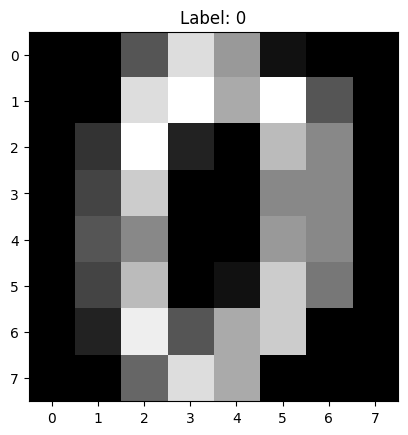

In [3]:
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

### **Step 2: Data Preprocessing and Normalization**

In this step, we preprocess the dataset to make it suitable for training the machine learning model. The pixel values in the dataset range from 0 to 16. To improve model performance, we normalize these values by scaling them between 0 and 1.

Normalization helps the model learn faster and improves accuracy by ensuring that all input features are on a similar scale.

In [4]:
# Normalize data (scale pixel values from 0–16 to 0–1)
X = X / 16.0

# Check sample values
print("Sample normalized data:", X[0][:10])

Sample normalized data: [0.     0.     0.3125 0.8125 0.5625 0.0625 0.     0.     0.     0.    ]


### **Step 3: Data Splitting (Training and Testing)**

In this step, the dataset is divided into two parts: training data and testing data. The training data is used to train the machine learning model, while the testing data is used to evaluate its performance.

This helps to check how well the model performs on unseen data and prevents overfitting.

In [5]:
from sklearn.model_selection import train_test_split

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1437, 64)
Testing data: (360, 64)


### **Step 4: Model Training**

In this step, machine learning models are trained using the training dataset. Two different algorithms are used: K-Nearest Neighbors (KNN) and Support Vector Machine (SVM).

KNN classifies data based on the nearest neighbors, while SVM finds the optimal boundary to separate different classes. Using multiple models helps in comparing their performance and selecting the best one for accurate digit recognition.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# SVM Model
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

print("Models trained successfully")

Models trained successfully


### **Step 5: Model Evaluation and Comparison**

In this step, the performance of the trained models is evaluated using the testing dataset. The accuracy of each model is calculated to determine how well it can predict unseen data.

By comparing the accuracy of different models such as KNN and SVM, the best performing model can be selected for handwritten digit recognition.

In [7]:
from sklearn.metrics import accuracy_score

# KNN Predictions
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

# SVM Predictions
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

# Print results
print("KNN Accuracy:", knn_accuracy)
print("SVM Accuracy:", svm_accuracy)

KNN Accuracy: 0.9833333333333333
SVM Accuracy: 0.9861111111111112


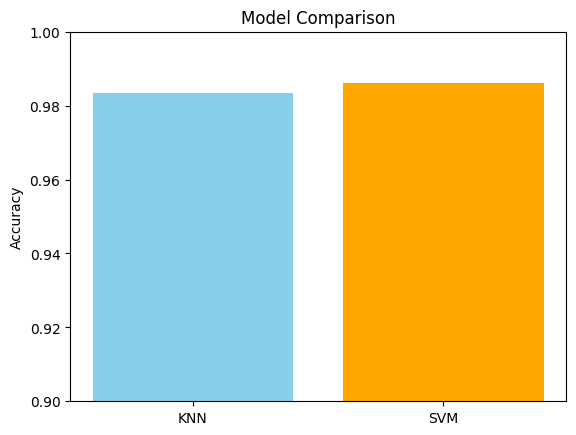

In [8]:
import matplotlib.pyplot as plt

models = ['KNN', 'SVM']
accuracies = [knn_accuracy, svm_accuracy]

colors = ['skyblue', 'orange']  # different colors

plt.bar(models, accuracies, color=colors)
plt.ylim(0.9, 1.0)  # zoom into accuracy range
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

### **Step 6: Confidence Score Calculation**

In this step, the model not only predicts the digit but also provides a confidence score. The confidence score represents how certain the model is about its prediction.

This is achieved using probability estimates, where the model assigns a probability to each possible digit (0–9). The digit with the highest probability is selected as the final prediction along with its confidence score.

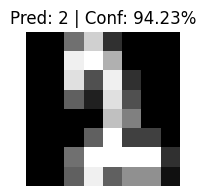

Actual Digit: 2


In [9]:
import random
import matplotlib.pyplot as plt

# Pick random index
idx = random.randint(0, len(X_test)-1)
sample = X_test[idx]

# Predict
prediction = svm_model.predict([sample])[0]
probabilities = svm_model.predict_proba([sample])[0]
confidence = max(probabilities)

# Show image
plt.figure(figsize=(2,2))
plt.imshow(sample.reshape(8,8), cmap='gray')
plt.title(f"Pred: {prediction} | Conf: {round(confidence*100,2)}%")
plt.axis('off')
plt.show()

print("Actual Digit:", y_test[idx])

### Step 7: Drawing-Based User Interface using Gradio

This step creates an **interactive interface** using the **Gradio** library, allowing users to **draw handwritten digits directly on a canvas** instead of uploading an image.

The drawn image is converted into a **numerical array**, resized to match the **8×8 format** of the training dataset, and normalized. The processed image is then passed to the **trained model**, which predicts the digit and shows a **confidence score**.

> ⚠️ **Tip:** For better accuracy, use a **medium brush size** and draw the digit **near the center of the canvas**, as thin or off-center drawings may be misclassified.

For a more accurate prediction system, see the last cell below.

In [10]:
!pip install gradio

In [11]:
import gradio as gr
import numpy as np
from PIL import Image, ImageOps
from sklearn import datasets, svm

# =========================
# Train Model
# =========================
digits = datasets.load_digits()
X = digits.data / 16.0
y = digits.target

svm_model = svm.SVC(kernel='rbf', probability=True)
svm_model.fit(X, y)


# =========================
# Prediction Function (FIXED)
# =========================
def predict_digit(img):
    try:
        # ✅ FIXED input handling (no 'or' with numpy)
        if isinstance(img, dict):
            if "composite" in img and img["composite"] is not None:
                img = img["composite"]
            elif "image" in img and img["image"] is not None:
                img = img["image"]
            else:
                return "Draw something first!"

        if img is None:
            return "Draw something first!"

        if isinstance(img, np.ndarray) and img.size == 0:
            return "Draw something first!"

        # Convert to PIL
        img = Image.fromarray(img.astype('uint8')).convert('L')

        # Invert
        img = ImageOps.invert(img)

        # Resize
        img = img.resize((8, 8), Image.BILINEAR)

        # Convert to numpy
        img_array = np.array(img)

        # Clean noise
        img_array = (img_array > 50) * img_array

        # Normalize
        img_array = (img_array / 255.0) * 16

        # Flatten
        img_flat = img_array.flatten().reshape(1, -1)

        # Predict
        prediction = svm_model.predict(img_flat)[0]
        confidence = max(svm_model.predict_proba(img_flat)[0])

        return f"Prediction: {prediction} | Confidence: {round(confidence*100,2)}%"

    except Exception as e:
        return f"Error: {str(e)}"


# =========================
# UI
# =========================
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(type="numpy"),
    outputs=gr.Textbox(lines=2),
    title="🧠 Handwritten Digit Recognition",
    description="Draw a digit (0–9) clearly and click Submit"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b53042bcd0aa75d26.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### **Step 8: Random Test Image Selection and Prediction**

In this step, the system provides an interactive feature to select and recognize handwritten digits from unseen data. When the user clicks the **"Get Random Image"** button, the system randomly selects a digit image from the test dataset (X_test), which contains data that was not used during the training phase.

This ensures that the selected image is completely new to the model, allowing proper evaluation of its performance on unseen data.

Once the image is displayed, the user can click the **"Detect"** button. The selected image is then passed to the trained machine learning model. The model processes the input and predicts the corresponding digit by analyzing its pixel values.

Along with the predicted digit, the system also calculates a confidence score, which indicates how certain the model is about its prediction. The result displays the actual digit, predicted digit, confidence percentage, and whether the prediction is correct or not.

This step demonstrates real-time prediction and evaluation of the model using unseen data, making the system reliable and closer to real-world applications.

In [12]:
import gradio as gr
import numpy as np
import random
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Normalize
X = X / 16.0

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

# Global variables
current_sample = None
current_label = None

# Get random image
def get_random_image():
    global current_sample, current_label

    idx = random.randint(0, len(X_test)-1)
    current_sample = X_test[idx]
    current_label = y_test[idx]

    img = current_sample.reshape(8,8)
    img = np.kron(img, np.ones((20,20)))  # enlarge

    return img, f"Actual Digit: {current_label}\nClick Detect to predict"


# Detect digit
def detect_digit():
    global current_sample, current_label

    if current_sample is None:
        return np.zeros((160,160)), "Click 'Get Random Image' first!"

    prediction = svm_model.predict([current_sample])[0]
    confidence = max(svm_model.predict_proba([current_sample])[0])

    img = current_sample.reshape(8,8)
    img = np.kron(img, np.ones((20,20)))

    status = "✅ Correct" if prediction == current_label else "❌ Wrong"

    result = f"""Actual Digit: {current_label}
Prediction: {prediction}
Confidence: {round(confidence*100,2)}%
Result: {status}"""

    return img, result


# UI
with gr.Blocks() as demo:
    gr.Markdown("## 🧠 Handwritten Digit Recognition System")

    image_output = gr.Image(label="Digit Image", height=220, width=220)

    text_output = gr.Textbox(
        label="Result",
        lines=6,
        max_lines=10,
        show_copy_button=True
    )

    with gr.Row():
        btn_random = gr.Button("🎲 Get Random Image")
        btn_detect = gr.Button("🔍 Detect")

    btn_random.click(get_random_image, outputs=[image_output, text_output])
    btn_detect.click(detect_digit, outputs=[image_output, text_output])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://21225cba0c100e24b7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
# Step 1: Import and Train Model

import numpy as np
import random
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
digits = load_digits()
X = digits.data / 16.0   # normalize
y = digits.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [14]:
# Step 2: Generate Random Digit Sequence (Phone Number)

# Global storage
phone_samples = []
phone_labels = []

def generate_phone_number(n_digits=10):
    global phone_samples, phone_labels

    phone_samples = []
    phone_labels = []

    for _ in range(n_digits):
        idx = random.randint(0, len(X_test)-1)
        phone_samples.append(X_test[idx])
        phone_labels.append(y_test[idx])

    print("Generated Digits:", phone_labels)

    return phone_samples, phone_labels


# Test it
samples, labels = generate_phone_number()

Generated Digits: [np.int64(5), np.int64(7), np.int64(4), np.int64(4), np.int64(9), np.int64(1), np.int64(6), np.int64(1), np.int64(6), np.int64(6)]


In [15]:
# Step 3: Predict All Digits

def predict_phone_number():
    predictions = []
    confidences = []

    for sample in phone_samples:
        pred = svm_model.predict([sample])[0]
        prob = max(svm_model.predict_proba([sample])[0])

        predictions.append(str(pred))
        confidences.append(prob)

    # Combine digits into number
    phone_number = ''.join(predictions)

    # Average confidence
    avg_conf = sum(confidences) / len(confidences)

    print("Predicted Number:", phone_number)
    print("Confidence:", round(avg_conf * 100, 2), "%")

    return phone_number, avg_conf


# Test it
predict_phone_number()

Predicted Number: 5744916166
Confidence: 97.92 %


('5744916166', np.float64(0.9791805695299736))

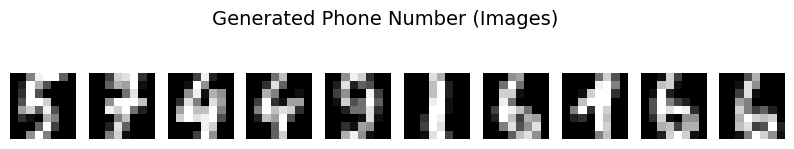

In [16]:
# Step 4: Display digits in a row

import matplotlib.pyplot as plt

def show_phone_number():
    plt.figure(figsize=(10, 2))

    for i, sample in enumerate(phone_samples):
        plt.subplot(1, len(phone_samples), i + 1)
        plt.imshow(sample.reshape(8, 8), cmap='gray')
        plt.axis('off')

    plt.suptitle("Generated Phone Number (Images)", fontsize=14)
    plt.show()


# Test it
show_phone_number()

### **Step 10: Phone Number Pattern Recognition**

In this step, the system is extended from single digit recognition to multi-digit sequence recognition, simulating a real-world application such as phone number detection.

When the user clicks the **"Generate Number"** button, the system randomly selects multiple digit images from the test dataset (X_test). Since this dataset was not used during training, the selected images represent unseen data. These individual digit images are then arranged side-by-side to visually form a sequence similar to a phone number. At the same time, their corresponding labels are combined to form the actual number.

After generating the sequence, the user can click the **"Predict"** button. The system processes each digit image one by one using the trained machine learning model. For each image, the model predicts the digit and calculates a confidence score. These predicted digits are then combined (stitched together) to form the final detected number.

Finally, the system displays the actual number, predicted number, average confidence score, and whether the prediction is correct or not. This step demonstrates how a basic digit recognition model can be extended to handle multi-digit patterns, similar to simple OCR applications.

In [17]:
import gradio as gr
import matplotlib.pyplot as plt

# Generate + display
def generate_and_show():
    generate_phone_number()

    # Create image
    fig, axes = plt.subplots(1, len(phone_samples), figsize=(10, 2))

    for i, sample in enumerate(phone_samples):
        axes[i].imshow(sample.reshape(8,8), cmap='gray')
        axes[i].axis('off')

    plt.tight_layout()

    actual_number = ''.join(str(d) for d in phone_labels)

    return fig, f"Actual Number: {actual_number}\nClick Predict to detect", actual_number


# Predict
def predict_full_number(actual_number):
    number, conf = predict_phone_number()

    # Recreate image
    fig, axes = plt.subplots(1, len(phone_samples), figsize=(10, 2))

    for i, sample in enumerate(phone_samples):
        axes[i].imshow(sample.reshape(8,8), cmap='gray')
        axes[i].axis('off')

    plt.tight_layout()

    status = "✅ Correct" if number == actual_number else "❌ Wrong"

    result = f"""Actual Number: {actual_number}
Detected Number: {number}
Confidence: {round(conf*100,2)}%
Result: {status}"""

    return fig, result


# UI
with gr.Blocks() as demo:
    gr.Markdown("## 📱 Phone Number Recognition System")

    image_output = gr.Plot()
    text_output = gr.Textbox(lines=5)

    # 🔥 State to store actual number
    state = gr.State()

    with gr.Row():
        btn_generate = gr.Button("🎲 Generate Number")
        btn_predict = gr.Button("🔍 Predict")

    btn_generate.click(
        generate_and_show,
        outputs=[image_output, text_output, state]
    )

    btn_predict.click(
        predict_full_number,
        inputs=state,
        outputs=[image_output, text_output]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f15ccec9c775f6a268.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
